<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/01-PyTorch/02-PyTorch-Computer-Vision/02_food101_cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

!pip install torchmetrics
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 60.3 MB/s eta 0:00:00


In [2]:
custom_transform=torchvision.transforms.Compose([
                                                 torchvision.transforms.ToTensor(),
                                                 torchvision.transforms.Resize((224,224)),
                                                 torchvision.transforms.ColorJitter(brightness=0.2,
                                                                                    contrast=0.2,
                                                                                    saturation=0.2,
                                                                                    hue=0.1
                                                                                    )
                                                ])
train_dataset=datasets.Food101(root="data",
                               download=True,
                               transform=custom_transform,
                               split="train")

test_dataset=datasets.Food101(root="data",
                              download=True,
                              transform=custom_transform,
                              split="test")

100%|██████████| 5.00G/5.00G [03:46<00:00, 22.1MB/s]


In [3]:
train_dataset,test_dataset

(Dataset Food101
     Number of datapoints: 75750
     Root location: data
     split=train
     StandardTransform
 Transform: Compose(
                ToTensor()
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
            ),
 Dataset Food101
     Number of datapoints: 25250
     Root location: data
     split=test
     StandardTransform
 Transform: Compose(
                ToTensor()
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
            ))

In [4]:
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [10]:
print("These are the classes in this dataset \n")
for i in range(len(train_dataset.classes)):
  print(f"{train_dataset.classes[i]}")

These are the classes in this dataset 

apple_pie
baby_back_ribs
baklava
beef_carpaccio
beef_tartare
beet_salad
beignets
bibimbap
bread_pudding
breakfast_burrito
bruschetta
caesar_salad
cannoli
caprese_salad
carrot_cake
ceviche
cheese_plate
cheesecake
chicken_curry
chicken_quesadilla
chicken_wings
chocolate_cake
chocolate_mousse
churros
clam_chowder
club_sandwich
crab_cakes
creme_brulee
croque_madame
cup_cakes
deviled_eggs
donuts
dumplings
edamame
eggs_benedict
escargots
falafel
filet_mignon
fish_and_chips
foie_gras
french_fries
french_onion_soup
french_toast
fried_calamari
fried_rice
frozen_yogurt
garlic_bread
gnocchi
greek_salad
grilled_cheese_sandwich
grilled_salmon
guacamole
gyoza
hamburger
hot_and_sour_soup
hot_dog
huevos_rancheros
hummus
ice_cream
lasagna
lobster_bisque
lobster_roll_sandwich
macaroni_and_cheese
macarons
miso_soup
mussels
nachos
omelette
onion_rings
oysters
pad_thai
paella
pancakes
panna_cotta
peking_duck
pho
pizza
pork_chop
poutine
prime_rib
pulled_pork_sandwich


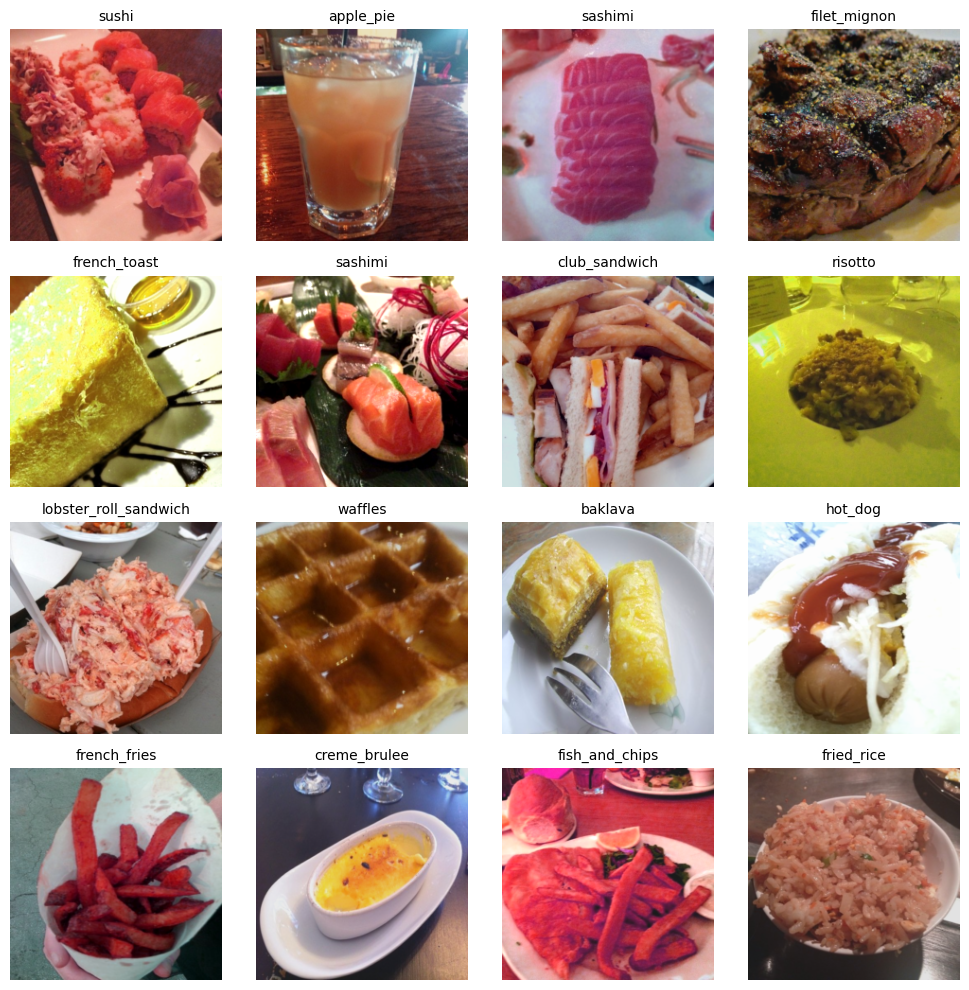

In [11]:
import random

plt.figure(figsize=(10,10))
for i in range (16):
  idx=random.randint(0,len(train_dataset)-1)
  img,label=train_dataset[idx]
  class_name=train_dataset.classes[label]

  plt.subplot(4,4,i+1)
  plt.imshow(img.permute(1,2,0))              #Pytorch uses [C,H,W] While Matplotlib uses [H,W,C]
  plt.title(class_name, fontsize=10)
  plt.axis('off')

plt.tight_layout()   #Adjusts spacing
plt.show()

In [12]:
BATCH_SIZE=32
train_dataloader=DataLoader(dataset=train_dataset,
                            num_workers=2,
                            batch_size=BATCH_SIZE,
                            pin_memory=True,
                            shuffle=True)

test_dataloader=DataLoader(dataset=test_dataset,
                           num_workers=2,
                           batch_size=BATCH_SIZE,
                           pin_memory=True,
                           shuffle=False)

In [13]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c0454f0c440>,
 <torch.utils.data.dataloader.DataLoader at 0x7c04550f74d0>)

In [15]:
img_batch,label_batch=next(iter(train_dataloader))     # taking a batch of size 32 that means it going to gave 32 images with there labels
img_batch.shape,label_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [26]:
class CNNfood101model(nn.Module):
  def __init__(self,input_shape,hidden_units,output_shape):
    super().__init__()

    self.seq_conv_block_1=nn.Sequential(
                                      nn.Conv2d(in_channels=input_shape,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(in_channels=hidden_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(
                                                in_channels=hidden_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=1),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size=2)
                                      )
    self.seq_conv_block_2=nn.Sequential(
                                      nn.Conv2d(in_channels=hidden_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(in_channels=hidden_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(
                                                in_channels=hidden_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=1),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size=2)
                                      )
    self.classifier=nn.Sequential(
                                nn.Flatten(),
                                nn.Linear(in_features=hidden_units*56*56,      #how 56*56 as our original was (224,224) as we have use two maxpool2d the 224/4=56 hence ours in_features becomes 56*56 after flatten
                                          out_features=output_shape)
                                )
  def forward(self,x):
    x=self.seq_conv_block_1(x)
    x=self.seq_conv_block_2(x)
    x=self.classifier(x)
    return x

CNN_food101=CNNfood101model(input_shape=3,
                            hidden_units=10,
                            output_shape=len(train_dataset.classes)).to(device)
CNN_food101

CNNfood101model(
  (seq_conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (seq_conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=31360, out_features=101, bias=True)
  )
)

In [27]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=CNN_food101.parameters(),
                           lr=0.001)
accuracy_fn=torchmetrics.Accuracy(task='multiclass',num_classes=len(train_dataset.classes)).to(device)

In [29]:
from tqdm.auto import tqdm

ecophs=5

for ecophs in tqdm(range(ecophs)):
  print(f"Epoch: {ecophs}")

  train_loss=0
  train_acc=0

  CNN_food101.train()

  for batch,(X,y) in enumerate(train_dataloader):
    X,y=X.to(device),y.to(device)

    y_pred=CNN_food101(X)

    loss=loss_fn(y_pred,y)
    train_loss+=loss.item()                                # Using .item to prevent RAM leak
    train_acc+=accuracy_fn(y_pred.argmax(dim=1),y).item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch%100==0:
      print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")


  train_loss/=len(train_dataloader)
  train_acc/=len(train_dataloader)
  print(f"Train_loss: {train_loss:.4f}, Train_acc: {train_acc:.4f}")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
Looked at 0/75750 samples
Looked at 3200/75750 samples
Looked at 6400/75750 samples
Looked at 9600/75750 samples
Looked at 12800/75750 samples
Looked at 16000/75750 samples


KeyboardInterrupt: 